In [1]:
from pymongo import MongoClient
import os
from dotenv import load_dotenv
import time
load_dotenv()
local_connection = MongoClient("mongodb://localhost:27017")
klg_connection = MongoClient(os.environ.get("ENTITIES_DB"))
protocol_connection = MongoClient(os.environ.get("DAPP_INFO_DB"))
klg_database = klg_connection["knowledge_graph"]
local_database = local_connection["blockchain_etl"]
protocol_database = protocol_connection["SmartContractLabel"]

In [2]:
chain_collection = {
    "0x38": "bnb",
    "0x89": "poly",
    "0x1": "eth",
    "0xa4b1": "arb"
}
timestamps = [i for i in range(1719792000, 1727740800, 86400)]

In [6]:
def round_timestamp(timestamp, round_time=86400):
    timestamp = int(timestamp)
    timestamp_unit_day = timestamp / round_time
    recover_to_unit_second = int(timestamp_unit_day) * round_time
    return recover_to_unit_second
    
def get_price(chain_id, token,E timestamp, price_tokens):
    cursor = price_tokens.get(token)
    if not cursor:
        cursor = klg_database["smart_contracts"].find_one({"_id": f"{chain_id}_{token}".lower()})
        price_tokens[token] = cursor
    price = 0
    
    if cursor.get("priceChangeLogs"):
        tmp = time.time()
        for ts, p in cursor.get("priceChangeLogs").items():
            if int(ts) <= tmp and int(ts) >= timestamp:
                price = p
                tmp = int(ts)
    elif cursor.get("price"):
        price = cursor.get("price")
    return price

def get_protocol_information(chain):
    exchange_rate = {}
    protocols = {}
    underlying = {}
    for item in protocol_database["protocols"].find({
        "chainId": chain,
        "$or":[
            {"_id": {"$regex": "aave"}},
            {"_id": {"$regex": "venus"}},
            {"_id": {"$regex": "compound"}}
        ]
    }):
        if "compound-v3" in item.get("_id") or "morpho-compound" in item.get("_id") or "morpho-aave" in item.get("_id"):
            continue 
        if "aave" in item.get("_id"):
            protocols[item.get("address")] = "aave"
        if "compound" in item.get("_id") or "venus" in item.get("_id"):
            for token in item["reservesList"]:
                ctoken = item['reservesList'][token]['cToken']
                underlying[ctoken] = token
                protocols[ctoken] = "compound"
                exchange_rate[ctoken] =  item['reservesList'][token]["exchangeRate"]
    return exchange_rate, protocols, underlying

In [6]:
result = {}
token_price = {}
for chain, prefix in chain_collection.items():
    exchange_rate, protocols, underlyings = get_protocol_information(chain)
    result[chain] = {
        str(i):{
            "wallets": [],
            "events": 0,
            "amount": 0
        } for i in timestamps
    }
    cursor = local_database[f"{prefix}_lq_events"].find({"contract_address": {"$in": list(protocols.keys())}})
    for event in cursor:
        round_time = round_timestamp(event.get("block_timestamp"))
        if round_time not in timestamps:
            continue
        contract_address = event.get("contract_address")
        amount = 0
        if protocols.get(contract_address) == "aave":
            debt_token = event.get("debt_asset")
            amount = event.get("debt_to_cover") * get_price(chain, debt_token, event.get("block_timestamp"), token_price)
        if protocols.get(contract_address) == "compound":
            underlying = underlyings.get(contract_address)
            amount = event.get("debt_to_cover") * exchange_rate.get(contract_address, 1) * get_price(chain, underlying, event.get("block_timestamp"), token_price)
        result[chain][str(round_time)]["events"] += 1
        result[chain][str(round_time)]["amount"] += amount
        if event.get("user") not in result[chain][str(round_time)]["wallets"]:
            result[chain][str(round_time)]["wallets"].append(event.get("user"))

In [7]:
import json
with open("analysis.json",'w') as f:
    json.dump(result, f, indent=1)

# Overview

In [8]:
import json
with open("analysis.json",'r') as f:
    data = json.loads(f.read())

In [9]:
total_wallets = []
total_events=0
total_amount=0
for chain_id, value in data.items():
    for timestamp, log in value.items():
        total_events += log.get("events")
        total_amount += log.get("amount")
        total_wallets += log.get("wallets")


In [10]:
total_amount

398832205.27027607

In [11]:
len(list(set(total_wallets)))

13753

In [12]:
import pandas
def descride_data(data, chain):
    chain_data = data[chain]
    data_dict = {'timestamp':[], 'wallets':[], 'events':[], 'amount':[]}
    wallets = []
    for timestamp, value in chain_data.items():
        wallets += value['wallets']
        data_dict['wallets'].append(len(value['wallets']))
        data_dict['events'].append(value['events'])
        data_dict['amount'].append(value['amount'])
        data_dict['timestamp'].append(timestamp)
    wallets = list(set(wallets))
    print(f'event/day: {sum(data_dict["events"])/len(data_dict["timestamp"])}')
    print(f'wallet/day: {sum(data_dict["wallets"])/len(data_dict["timestamp"])}')
    print(f'amount/day: {sum(data_dict["amount"])/len(data_dict["timestamp"])}')
    print(f'amount/event: {sum(data_dict["amount"])/sum(data_dict["events"])}')
    print(f'amount/wallet: {sum(data_dict["amount"])/len(wallets)}')
    print(f'event/wallet: {sum(data_dict["events"])/len(wallets)}')
    df = pandas.DataFrame(data_dict)
    return df

In [13]:
bnb_df = descride_data(data, "0x38")
bnb_df.describe()

event/day: 20.26086956521739
wallet/day: 16.22826086956522
amount/day: 23146.431762472752
amount/event: 1142.4204517958653
amount/wallet: 2049.539674829156
event/wallet: 1.7940327237728586


,wallets,events,amount
count,92.000000,92.000000,9.200000e+01
mean,16.228261,20.260870,2.314643e+04
std,55.259051,77.983637,1.968698e+05
min,0.000000,0.000000,0.000000e+00
25%,1.000000,1.000000,1.609865e+00
50%,3.000000,3.000000,7.249282e+01
75%,8.250000,10.250000,6.957788e+02
max,437.000000,676.000000,1.886675e+06


In [14]:
poly_df = descride_data(data, "0x89")
poly_df.describe()

event/day: 118.67391304347827
wallet/day: 91.96739130434783
amount/day: 172906.15688979978
amount/event: 1456.985385039529
amount/wallet: 3040.9800102966124
event/wallet: 2.087172624737144


,wallets,events,amount
count,92.000000,92.000000,9.200000e+01
mean,91.967391,118.673913,1.729062e+05
std,323.410719,479.428027,1.013815e+06
min,4.000000,5.000000,1.157150e+01
25%,17.000000,18.000000,1.598810e+03
50%,26.000000,28.000000,4.347857e+03
75%,36.500000,43.000000,2.050583e+04
max,2802.000000,4343.000000,9.468683e+06


In [15]:
eth_df = descride_data(data, "0x1")
eth_df.describe()

event/day: 79.75
wallet/day: 61.130434782608695
amount/day: 3775175.485848766
amount/event: 47337.62364700647
amount/wallet: 95679.378704707
event/wallet: 2.021212121212121


,wallets,events,amount
count,92.000000,92.000000,9.200000e+01
mean,61.130435,79.750000,3.775175e+06
std,169.687251,277.534737,2.651888e+07
min,0.000000,0.000000,0.000000e+00
25%,3.000000,3.000000,1.442364e+03
50%,15.500000,16.000000,5.295307e+03
75%,50.000000,54.250000,6.304373e+04
max,1477.000000,2526.000000,2.522881e+08


In [16]:
arb_df = descride_data(data, "0xa4b1")
arb_df.describe()

event/day: 78.81521739130434
wallet/day: 64.6304347826087
amount/day: 363904.5914802234
amount/event: 4617.186928172742
amount/wallet: 7757.002413387524
event/wallet: 1.6800278035217795


,wallets,events,amount
count,92.000000,92.000000,9.200000e+01
mean,64.630435,78.815217,3.639046e+05
std,231.016517,327.294132,2.552724e+06
min,0.000000,0.000000,0.000000e+00
25%,3.000000,3.000000,6.073619e+01
50%,5.000000,5.000000,7.284821e+02
75%,13.000000,15.250000,7.813105e+03
max,1868.000000,2882.000000,2.421714e+07


# Adnormal

In [17]:
bnb_df["timestamp"][bnb_df["wallets"]>200].values

array(['1720137600', '1722297600', '1722816000'], dtype=object)

In [18]:
eth_df["timestamp"][eth_df["wallets"]>200].values

array(['1720137600', '1722729600', '1722816000', '1724803200',
       '1725580800'], dtype=object)

In [19]:
poly_df["timestamp"][poly_df["wallets"]>200].values

array(['1720051200', '1720137600', '1722729600', '1722816000',
       '1724716800', '1725580800'], dtype=object)

In [20]:
arb_df["timestamp"][arb_df["wallets"]>200].values

array(['1720051200', '1720137600', '1722729600', '1722816000',
       '1722988800', '1725062400', '1725408000', '1725494400',
       '1725580800'], dtype=object)

# Normal Wallets

In [21]:
def get_normal_wallets(df, data, chain):
    timestamp = list(df["timestamp"][df["wallets"]>=200])
    wallets = []
    adnormal_wallets = []
    for key, value in data[chain].items():
        if key in timestamp:
            adnormal_wallets += value["wallets"]
        wallets += value["wallets"]

    wallets = list(set(wallets))
    adnormal_wallets = list(set(adnormal_wallets))
    normal_wallets = [w for w in wallets if w not in adnormal_wallets]
    print(f"total: {len(wallets)}")
    print(f"adnormal: {len(adnormal_wallets)}")
    print(f"normal: {len(normal_wallets)}")
    return wallets, normal_wallets, adnormal_wallets

In [22]:
all_bnb, bnb_nv, bnb_av = get_normal_wallets(bnb_df, data, "0x38")

total: 1039
adnormal: 763
normal: 276


In [23]:
all_poly, poly_nv, poly_av = get_normal_wallets(poly_df, data, "0x89")

total: 5231
adnormal: 3764
normal: 1467


In [24]:
all_arb, arb_nv, arb_av = get_normal_wallets(arb_df, data, "0xa4b1")

total: 4316
adnormal: 4005
normal: 311


In [25]:
all_eth, eth_nv, eth_av = get_normal_wallets(eth_df, data, "0x1")

total: 3630
adnormal: 2224
normal: 1406


In [26]:
len(list(set(all_bnb+all_poly+all_arb+all_eth)))

13753

In [27]:
chain_collection = {
    "0x38": "blockchain_etl",
    "0x89": "polygon_blockchain_etl",
    "0x1": "ethereum_blockchain_etl",
    "0xa4b1": "arbitrum_blockchain_etl"
}
timestamps = {
    "0x38": ['1720137600', '1722297600', '1722816000'],
    "0x89":['1720051200', '1720137600', '1722729600', '1722816000',
       '1724716800', '1725580800'],
    "0x1":['1720137600', '1722729600', '1722816000', '1724803200',
       '1725580800'],
    "0xa4b1": ['1720051200', '1720137600', '1722729600', '1722816000',
       '1722988800', '1725062400', '1725408000', '1725494400',
       '1725580800']
}

def get_debt_most_asset(chain_id):
    remove_wallet = []
    wallet_liquidation1, wallet_liquidation2 = [], []
    number_small_events = 0
    number_large_events = 0
    start_time, end_time = 1719792000, 1727740800
    print(chain_collection.get(chain_id))
    for debtor in local_connection[chain_collection.get(chain_id)]["debtors"].find():
        address = debtor.get("_id")
        count = 0
        for pool, log in debtor.get("buyers").items():
            for timestamp, value in log.items():
                if start_time <= int(timestamp) < end_time:
                    if value.get("debtAssetInUSD") < 10:
                        number_small_events += 1
                        if address not in remove_wallet:
                            remove_wallet.append(address)
                    
                    if value.get("debtAssetInUSD") > 50000:
                        number_large_events += 1
                        if address not in remove_wallet:
                            remove_wallet.append(address)
                    count += 1
                    amount = value.get("debtAssetInUSD")
                if str(round_timestamp(int(timestamp))) in timestamps.get(chain_id):
                    if address not in remove_wallet:
                        remove_wallet.append(address)
        if count > 5:
            wallet_liquidation1.append(address)
            if address not in remove_wallet:
                        remove_wallet.append(address)
        if amount < 10 and count == 1:
            wallet_liquidation2.append(address)
    print(number_small_events)
    print(number_large_events)
    print(len(wallet_liquidation1))
    print(len(wallet_liquidation2))
    return remove_wallet

In [28]:
normal_wallets = bnb_nv + poly_nv + arb_nv + eth_nv
adnormal_wallets = bnb_av + poly_av + arb_av + eth_av
for chain_id in timestamps:
    adnormal_wallets += get_debt_most_asset(chain_id)
normal_wallets = list(set(normal_wallets))
adnormal_wallets = list(set(adnormal_wallets))
print(len(normal_wallets))
print(len(adnormal_wallets))
normal_wallets = [i for i in normal_wallets if i not in adnormal_wallets ]
print(len(normal_wallets))

blockchain_etl
705
59
39
303
polygon_blockchain_etl
2827
29
213
735
ethereum_blockchain_etl
176
876
164
27
arbitrum_blockchain_etl
2978
145
168
1498
3444
12439
2369


In [29]:
chains = {
    "bnb": "0x38",
    "ethereum": "0x1",
    "polygon": "0x89",
    "arbitrum": "0xa4b1"
}

wallet_type = {}
cursor = klg_connection["knowledge_graph"]["wallets"].find({"address":{"$in": normal_wallets}}, ["type", "address", "tags"])
for wallet in cursor:
    address = wallet.get("address")
    if wallet.get(address) == "contract":
        continue
    if wallet.get("type") == "contract":
        wallet_type[address] = "contract"
        continue
    elif wallet.get("foundation"):
        wallet_type[address] = "project"
        continue
    check = False
    for tag in wallet.get("tags", []):
        if "aave" in tag or "compound" in tag or "venus" in tag:
            check = True
            break
    if not check:
        continue
    if address not in wallet_type:
        wallet_type[address] = "wallet"
with open("debtor_type2.json", 'w') as f:
    json.dump(wallet_type, f, indent=1)

In [30]:
with open("debtor_type2.json", 'r') as f:
    wallet_type = json.loads(f.read())
wallet_debtors = [key for key, value in wallet_type.items() if value == "wallet"]
len(wallet_debtors)

1850

In [38]:
chain_id = ["0x1", "0x38", "0xa4b1", "0x89"]
for wallet in klg_connection["knowledge_graph"]["multichain_wallets"].find({"_id":{"$in": wallet_debtors}}):
    try:
        update_data = {
            "_id": wallet["_id"],
            "address": wallet["address"],
            "createdAt": wallet["createdAt"],
            "lendings": {key: value for key, value in wallet["lendings"].items() if key.split("_")[0] in chain_id},
            "tokenChangeLogs": {key: value for key, value in wallet.get("tokenChangeLogs", {}).items() if key.split("_")[0] in chain_id},
            "depositTokenChangeLogs": {key: value for key, value in wallet["depositTokenChangeLogs"].items() if key.split("_")[0] in chain_id},
            "borrowTokenChangeLogs": {key: value for key, value in wallet["borrowTokenChangeLogs"].items() if key.split("_")[0] in chain_id},
            "balanceChangeLogs": wallet.get("balanceChangeLogs", {})
        }
        local_connection["knowledge_graph"]["multichain_wallets"].insert_one(update_data)
    except:
        print(wallet.get("_id"))
    

# Normal wallets

In [2]:
one_time_w = []
multi_time_w = []
none_lq_w = []
for wallet in local_connection["knowledge_graph"]["multichain_wallets"].find({}):
    count = 0
    if "liquidationLogs" not in wallet:
        none_lq_w.append(wallet["address"])
        continue
    min_time = time.time()
    max_time = 0
    for address, logs in wallet["liquidationLogs"]["liquidatedWallet"].items():
        for timestamp in logs:
            if 1719792000 <= int(timestamp) < 1727740800:
                count += 1
                if int(timestamp) > max_time:
                    max_time =  int(timestamp)
                if int(timestamp) < min_time:
                    min_time = int(timestamp)
    local_connection["knowledge_graph"]["multichain_wallets_credit_scores"].update_one({"_id":wallet.get('address')}, {'$set':{"count": count, "maxTime": str(max_time), "minTime": min_time}}, upsert=True)

# Debt Assets

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
df = {"f1":[], "f2":[], "f3":[], "f4":[], "f5":[], "f6":[], "f7":[], "f8":[], "f9":[], "f10":[], "f11":[], "f12":[], "f13":[], "f14":[]}
for wallet in local_connection["knowledge_graph"]["multichain_wallets_credit_scores"].find():
    min_time = str(wallet.get("minTime"))
    scores = list(wallet.get("scores").keys())
    scores.sort()
    score_dict = wallet.get("scores")
    i = 0
    if score_dict[min_time]["creditScore"] > score_dict[scores[i]]["creditScore"]:
        df["f1"].append(score_dict[scores[i]]["creditScorex1"][0] - score_dict[min_time]["creditScorex1"][0])
        df["f2"].append(score_dict[scores[i]]["creditScorex1"][1] - score_dict[min_time]["creditScorex1"][1])
        df["f3"].append(score_dict[scores[i]]["creditScorex2"][0] - score_dict[min_time]["creditScorex2"][0])
        df["f4"].append(score_dict[scores[i]]["creditScorex2"][1] - score_dict[min_time]["creditScorex2"][1])
        df["f5"].append(score_dict[scores[i]]["creditScorex2"][2] - score_dict[min_time]["creditScorex2"][2])
        df["f6"].append(score_dict[scores[i]]["creditScorex2"][3] - score_dict[min_time]["creditScorex2"][3])
        df["f7"].append(score_dict[scores[i]]["creditScorex3"][0] - score_dict[min_time]["creditScorex3"][0])
        df["f8"].append(score_dict[scores[i]]["creditScorex3"][1] - score_dict[min_time]["creditScorex3"][1])
        df["f9"].append(score_dict[scores[i]]["creditScorex4"][0] - score_dict[min_time]["creditScorex4"][0])
        df["f10"].append(score_dict[scores[i]]["creditScorex4"][1] - score_dict[min_time]["creditScorex4"][1])
        df["f11"].append(score_dict[scores[i]]["creditScorex4"][2] - score_dict[min_time]["creditScorex4"][2])
        df["f12"].append(score_dict[scores[i]]["creditScorex5"][0] - score_dict[min_time]["creditScorex5"][0])
        df["f13"].append(score_dict[scores[i]]["creditScorex5"][1] - score_dict[min_time]["creditScorex5"][1])
        df["f14"].append(score_dict[scores[i]]["creditScorex6"][0] - score_dict[min_time]["creditScorex6"][0])
df = pd.DataFrame(df)

In [8]:
df.describe()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14
count,82.0,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,0.0,-186.414634,-123.487805,-131.817073,-130.353659,-123.097561,-9.463415,-111.695122,-11.292683,77.743902,15.841463,-9.230732,-121.612683,-0.926829
std,0.0,177.652383,186.704973,181.250194,173.841873,172.264555,118.123099,159.697375,18.998692,23.897317,31.133512,23.054333,134.942478,189.925897
min,0.0,-466.000000,-413.000000,-441.000000,-444.000000,-433.000000,-461.000000,-425.000000,-71.000000,0.000000,0.000000,-86.360000,-269.520000,-550.000000
25%,0.0,-361.000000,-372.000000,-346.000000,-311.000000,-358.000000,0.000000,-286.000000,-12.750000,85.000000,0.250000,0.000000,-269.520000,0.000000
50%,0.0,-102.000000,-8.000000,-20.500000,-35.000000,-18.000000,0.000000,-29.500000,-1.000000,85.000000,3.000000,0.000000,0.000000,0.000000
75%,0.0,-11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.500000,0.000000,85.000000,13.000000,0.000000,0.000000,0.000000
max,0.0,0.000000,372.000000,346.000000,311.000000,32.000000,371.000000,306.000000,0.000000,85.000000,166.000000,0.000000,0.000000,550.000000


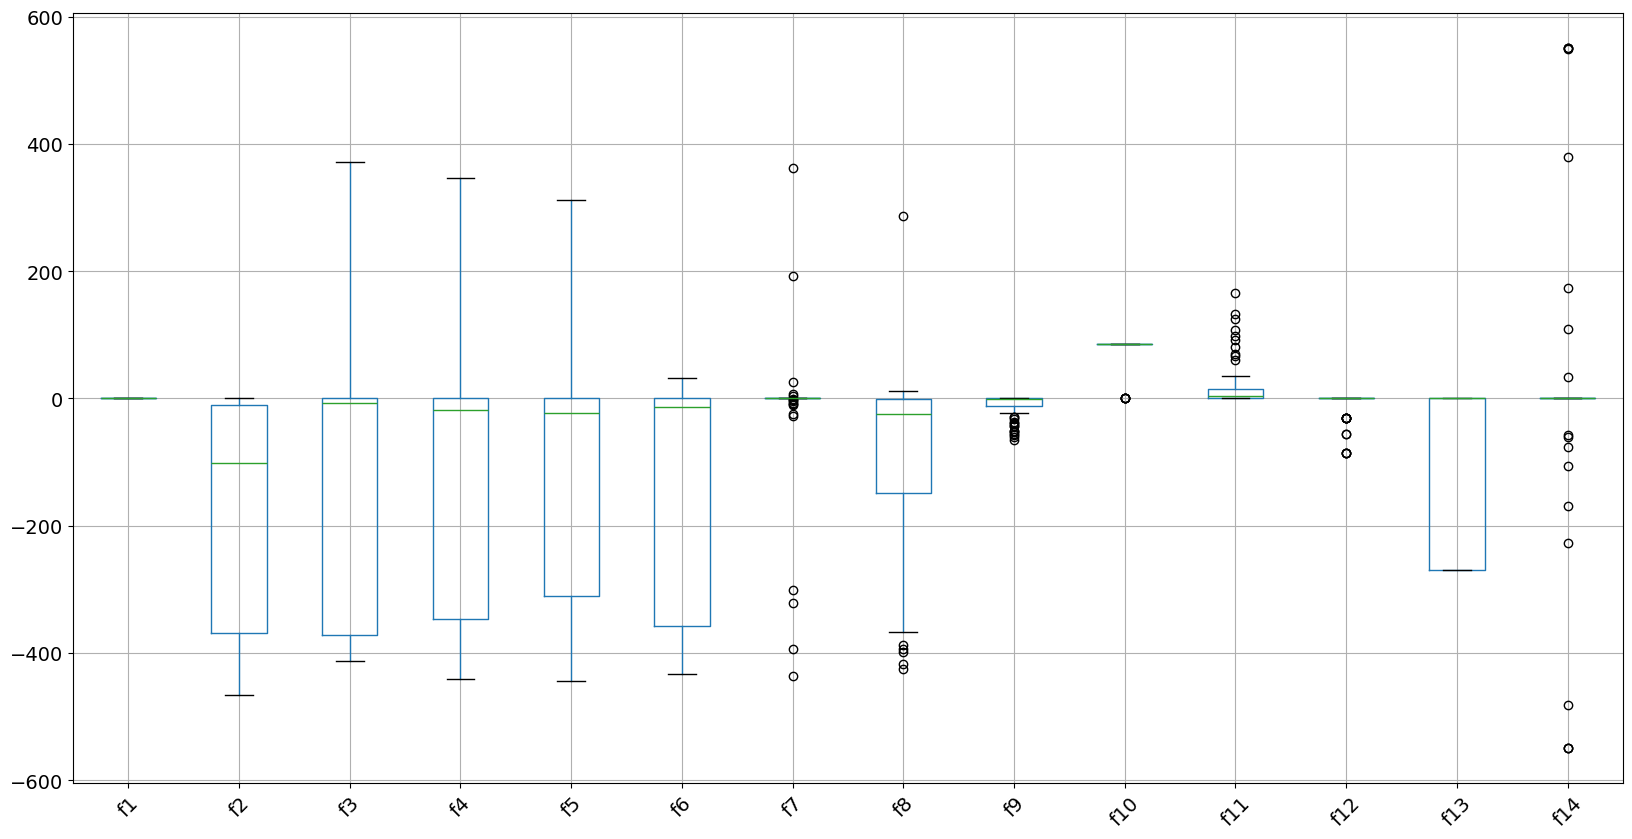

In [6]:
ax = df.boxplot(column=[pos for pos in df.keys()], fontsize=14, figsize=(20, 10))
plt.xticks(rotation=45)
plt.savefig("adnormal.png")

In [28]:
count_good_fair = []
count_fair_poor = []
count_good_poor = []
count_good = 0
count_fair = 0
count_poor = 0
for wallet in local_connection["knowledge_graph"]["multichain_wallets_credit_scores"].find({"count": {"$gte":1}}):
    min_time = str(wallet.get("maxTime"))
    scores = list(wallet.get("scores").keys())
    scores.sort()
    score_dict = wallet.get("scores")
    i = 0
    fist_score = score_dict[scores[i]]["creditScore"]
    min_time_score = score_dict[min_time]["creditScore"]
    if 670 <= fist_score <= 739:
        count_good += 1
    if 670 <= fist_score <= 739 and 580 <= min_time_score <= 669:
        count_good_fair.append(wallet["address"])
        
    if 670 <= fist_score <= 739 and 580 > min_time_score:
        count_good_poor.append(wallet["address"])

    if 580 <= fist_score <= 669:
        count_fair += 1

    if 580 <= fist_score <= 669:
        count_poor += 1
        
    if 580 <= fist_score <= 669 and 580 > min_time_score:
        count_fair_poor.append(wallet["address"])